# `py4conjoint` — デモ

このノートブックは `py4conjoint` の基本的な **関数・属性・メソッド** を
合成データで動作確認するためのものです。

| セクション | 内容 |
|:---:|------|
| 0 | セットアップ |
| 1 | アンケートとアンケート結果のファイル |
| 2 | `pcr.forms_to_conjoint_data()` |
| 3 | `pcr.encode()` |
| 4 | `pcr.fit()` |
| 5 | `ConjointResult` のフィールド |
| 6 | `result.warnings()` |
| 7 | `result.importance()` |
| 8 | `result.unit_rating_money()` |
| 9 | `result.wtp()` |
| 10 | `result.market_share()` |
| 11 | 可視化（`plot_importance / plot_partworth / plot_wtp`） |

## 0. セットアップ

In [1]:
import numpy as np
import pandas as pd
import py4conjoint.rating as pcr

print(f"py4conjoint version: {pcr.__version__}")

py4conjoint version: 0.3.0


## 1. アンケートとアンケート結果のファイル

コンジョイント分析では **プロファイル** を回答者に提示し、各プロファイルを評価してもらいます。
ここでは価格・OS・カメラの 3 属性・各 2 水準（4 プロファイル）の設計を使用します。

| プロファイルID | price（万円） | os | camera |
|----------|:-----------:|:-----:|:------:|
| P1 | 6 | android | 標準 |
| P2 | 10 | apple | 標準 |
| P3 | 6 | apple | 高性能 |
| P4 | 10 | android | 高性能 |

Google Formで集めたアンケート結果`responses_os.csv`を使います。

## 2. `pcr.forms_to_conjoint_data()` — アンケートファイルの読み込み

Microsoft Forms（`.xlsx`）または Google Forms（`.csv`）の回答ファイルを
**long 形式 DataFrame** （1 行 = 1 人 × 1 プロファイル）に変換する関数です。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `responses_file` | str | — | アンケートファイルのパス（.xlsx / .csv） |
| `attributes` | DataFrame or dict | — | プロファイル設計（行：プロファイル、列：属性） |
| `n_profiles` | int | `None` | 提示したプロファイル枚数 |
| `forms` | str | `"microsoft"` | `"microsoft"` または `"google"` |
| `respondent_cols` | dict | `None` | 回答者属性として残したい列の対応辞書 |
| `profile_id_prefix` | str | `"P"` | プロファイルIDの接頭辞（P1, P2, ...） |
| `rating_colname` | str | `"rating"` | 出力 DataFrame の評点列名 |
| `respondent_id_colname` | str | `"回答者ID"` | 出力 DataFrame の回答者 ID 列名 |
| `profile_id_colname` | str | `"プロファイルID"` | 出力 DataFrame のプロファイル ID 列名 |
| `out_csv` | str | `None` | 変換後 DataFrame を CSV で保存するパス |

**返り値**: long 形式 DataFrame（列：回答者ID, プロファイルID, rating, 回答者属性, プロファイル属性）

In [2]:
profiles = {     # P1         P2       P3        P4
        "price":  [6,         10,      6,        10],
        "os":     ["android", "apple", "apple",  "android"],
        "camera": ["標準",     "標準",   "高性能", "高性能"],
}

In [3]:
df = pcr.forms_to_conjoint_data(
     responses_file="responses_os.csv",
     attributes = profiles,
     respondent_cols = {"性別":"gender"},
     forms="google"
)
df.head()

,回答者ID,プロファイルID,rating,gender,price,os,camera
0,1,P1,3,女性,6,android,標準
1,1,P2,3,女性,10,apple,標準
2,1,P3,7,女性,6,apple,高性能
3,1,P4,2,女性,10,android,高性能
4,2,P1,5,女性,6,android,標準


## 3. `pcr.encode()` — 効果コーディング（-1 / +1）

属性列を **効果コーディング（±1）** に自動変換する関数です。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `df` | DataFrame | — | long 形式のデータ |
| `reference_levels` | dict | — | `{"属性名": 基準水準}` の辞書。基準水準が `-1` になる |
| `binary_suffix_map` | dict | `None` | 2 水準属性の列名サフィックスを手動指定 |
| `respondent_encode` | dict | `None` | 回答者の基準属性とサフィックスを手動指定（値は`[基準属性、サフィックス]`） |
| `drop_original` | bool | `False` | 元の属性列を削除するか |
| `inplace` | bool | `False` | 入力 df を直接書き換えるか |

**返り値の列名ルール**
- 2 水準 → `{属性名}_0` が 1 列追加
- 3 水準以上 → `{属性名}_0`, `{属性名}_1`, … が K-1 列追加
- `binary_suffix_map` 指定時 → `{属性名}_{指定サフィックス}`
- `respondent_encode` → `{回答者属性}_{サフィックス}`

In [4]:
df_named = pcr.encode(
    df,
    reference_levels={"price": 10, "os": "android", "camera": "標準"},
    binary_suffix_map={"price": "low", "os": "apple", "camera": "high"},
    respondent_encode={"gender": ["女性", "female"]},
)

df_named.head()

/var/folders/_f/g_05tt3j09n5hcrk1mwhyj5r0000gn/T/ipykernel_26173/4165672079.py:1: DeprecationWarning: binary_suffix_map は非推奨です。suffix_map を使ってください。
例: suffix_map={'price': 'low', 'os': 'apple'}
  df_named = pc.encode(


,回答者ID,プロファイルID,rating,gender,price,os,camera,price_low,os_apple,camera_high,gender_female
0,1,P1,3,女性,6,android,標準,1,-1,-1,0
1,1,P2,3,女性,10,apple,標準,-1,1,-1,0
2,1,P3,7,女性,6,apple,高性能,1,1,1,0
3,1,P4,2,女性,10,android,高性能,-1,-1,1,0
4,2,P1,5,女性,6,android,標準,1,-1,-1,0


## 4. `pcr.fit()` — OLS 回帰

符号化済み DataFrame に OLS 回帰を適用し、`ConjointResult` を返す関数です。
欠損値の除外、日本語列名の自動エイリアス処理、落とし穴チェックを自動実行します。

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `df` | DataFrame | — | `encode()` 済みの DataFrame |
| `rating` | str | `"rating"` | 評点（被説明変数）の列名 |
| `price_col` | str | `"price"` | 価格列名。WTP 計算で使用 |
| `encoded_columns` | list of str | `None` | 説明変数リスト（省略時は自動検出） |
| `reference_levels` | dict | `None` | 基準水準辞書（`encode()` 経由なら自動取得） |
| `formula` | str | `None` | statsmodels 用の回帰式を直接指定 |
| `respondent_id_col` | str | `"回答者ID"` | 回答者ID列名（クラスタロバスト標準誤差と回答者数診断に使用） |
| `cluster_se` | bool | `True` | 回答者IDによるクラスタロバスト標準誤差を使用（係数は不変、p値が適正化） |

**返り値**: `ConjointResult` オブジェクト

In [5]:
result = pcr.fit(
    df_named,
    # encoded_columns=["price_low", "os_apple"],  # 使う列データを指定する場合
    price_col="price",  # 以下の分析に使われる
)

result

============================================================
コンジョイント分析の結果（和文サマリー）
============================================================
観測数        : 120
説明変数の数  : 3
決定係数 R²   : 0.9027
自由度修正 R² : 0.9002
標準誤差      : クラスタロバスト（回答者ID）

【推定された係数（部分効用 part-worth）】
  変数                            係数        p値  有意性
  ------------------------- ---------- ----------  ------
  Intercept                     3.8417     0.0000  ***
  price_low                     1.4583     0.0000  ***
  os_apple                      0.9083     0.0000  ***
  camera_high                   0.6583     0.0000  ***

  有意水準: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1
============================================================

## 5. `ConjointResult` のフィールド

### 5-A. プロパティ（頻繁に使う）

| プロパティ | 型 | 説明 |
|-----------|-----|------|
| `params` | `pd.Series` | 推定係数（切片含む） |
| `rsquared` | `float` | 決定係数 R² |
| `n_obs` | `int` | 分析に使用した観測数 |
| `intercept` | `float` | 切片 b₀（全水準平均の効用） |

### 5-B. データフィールド（中級者向け）

| フィールド | 型 | 説明 |
|-----------|-----|------|
| `rating` | `str` | 評点列名 |
| `encoded_columns` | `list` | 説明変数（符号化列）のリスト |
| `reference_levels` | `dict` | `encode()` に渡された基準水準辞書 |
| `price_col` | `str` | 価格列名 |
| `n_dropped` | `int` | 欠損除外された行数 |
| `alias_map` | `dict` | 符号化列名の内部エイリアスマップ（`formula=None` 時に生成、内部処理用） |
| `ols` | `RegressionResults` | statsmodels の生の推定結果 |

In [6]:
# プロパティ
print("result.params")
print(result.params)
print()
print(f"result.rsquared  = {result.rsquared:.4f}")
print(f"result.n_obs     = {result.n_obs}")
print(f"result.intercept = {result.intercept:.4f}")

result.params
Intercept      3.841667
price_low      1.458333
os_apple       0.908333
camera_high    0.658333
dtype: float64

result.rsquared  = 0.9027
result.n_obs     = 120
result.intercept = 3.8417


In [7]:
# データフィールド
print(f"result.rating            = {result.rating!r}")
print(f"result.encoded_columns   = {result.encoded_columns}")
print(f"result.reference_levels  = {result.reference_levels}")
print(f"result.price_col         = {result.price_col!r}")
print(f"result.n_dropped         = {result.n_dropped}")
print(f"result.alias_map         = {result.alias_map}")

result.rating            = 'rating'
result.encoded_columns   = ['price_low', 'os_apple', 'camera_high']
result.reference_levels  = {'price': 10, 'os': 'android', 'camera': '標準'}
result.price_col         = 'price'
result.n_dropped         = 0
result.alias_map         = {'price_low': '__pc_var_0__', 'os_apple': '__pc_var_1__', 'camera_high': '__pc_var_2__'}


In [8]:
# ols: statsmodels の RegressionResults をそのまま利用
print(result.ols.summary(slim=True))

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.900
No. Observations:                 120   F-statistic:                     729.2
Covariance Type:              cluster   Prob (F-statistic):           2.16e-27
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.8417      0.056     68.270      0.000       3.731       3.952
price_low       1.4583      0.058     25.002      0.000       1.344       1.573
os_apple        0.9083      0.041     22.079      0.000       0.828       0.989
camera_high     0.6583      0.068      9.664      0.000       0.525       0.792

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)


## 6. `result.warnings()` — 落とし穴チェック

回帰分析で自動検出された **診断警告** の一覧を返します。

**自動検出される警告の種類**

| カテゴリ | 重大度 | 検出タイミング | 内容 |
|----------|:------:|:-----------:|------|
| `r2_low` | 大 | `fit()` 直後 | R² < 0.20 |
| `obs_per_predictor` | 大/中 | `fit()` 直後 | 観測数／説明変数数の比率が低い（< 5 → 大、< 10 → 中） |
| `few_respondents` | 大/中 | `fit()` 直後 | 回答者数が少ない（1人 → 大、2〜4人 → 中、5人以上は警告なし） |
| `independence_assumed` | 中 | `fit()` 直後 | 回答者ID列が無く、観測の独立性を仮定した標準誤差を使用（p値が過小になる恐れ） |
| `price_sign_negative` | 中 | `fit()` 直後 | 価格係数の符号が逆かつ有意（価格↑で評点↑） |
| `price_insignificant` | 中 | `wtp()` 呼出時 | 価格の p 値 ≥ 0.10（3水準以上は同時F検定） |
| `wtp_extrapolation` | 中 | `wtp()` 呼出時 | \|WTP\| > 価格レンジ × 2 |

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `severity` | str / list | `None` | 重大度でフィルタ（`"大"`/`"中"`/`"小"`） |
| `category` | str / list | `None` | カテゴリ名でフィルタ |
| `as_dataframe` | bool | `True` | `True` → DataFrame、`False` → `Diagnostic` リスト |

**返り値**: `pd.DataFrame`（列: severity, category, message, recommendation）または `list[Diagnostic]`

In [9]:
# wtp() を先に呼んで価格関連の警告も生成させる（以下を参照）
result.wtp()

# 警告なしの場合は「データ品質は良好」
result.warnings()

,severity,category,message,recommendation


## 7. `result.importance()` — 重要度

各属性の **効用範囲（最大 − 最小）の比率** として重要度を計算します。

**計算式**
$$\text{importance}_i = \frac{\text{range}_i}{\sum_j \text{range}_j} \times 100$$

2 水準の場合の効用範囲 = `2 × |係数|`（水準が -1 と +1 なので差は 2 倍）

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `as_percent` | bool | `True` | `True` → 合計 100%、`False` → 合計 1.0 の比率 |

**返り値**: `pd.DataFrame`（インデックス: 属性名、列: `効用範囲`, `重要度`）

In [10]:
print("【as_percent=True（デフォルト）— 合計 100%】")
imp_pct = result.importance(as_percent=True)
print(imp_pct)
print(f"  合計: {imp_pct['重要度'].sum():.1f}%")

print()
print("【as_percent=False — 合計 1.0 の比率】")
imp_ratio = result.importance(as_percent=False)
print(imp_ratio)
print(f"  合計: {imp_ratio['重要度'].sum():.4f}")

【as_percent=True（デフォルト）— 合計 100%】
            効用範囲        重要度
属性                         
price   2.916667  48.209366
os      1.816667  30.027548
camera  1.316667  21.763085
  合計: 100.0%

【as_percent=False — 合計 1.0 の比率】
            効用範囲       重要度
属性                        
price   2.916667  0.482094
os      1.816667  0.300275
camera  1.316667  0.217631
  合計: 1.0000


## 8. `result.unit_rating_money()` — 評点 1 点の金額換算

評点 1 ポイントが何円（または何万円）に相当するかを返します。

**計算式**
$$\text{unit\_rating\_money} = \frac{\text{price\_range}}{|b_{\text{price}}| \times 2}$$

効果コーディングで価格変数の範囲が `-1` 〜 `+1` の 2 単位であることに由来します。  

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `price_col` | str | `None` | 価格列名（省略時は `fit()` の設定値） |

**返り値**: `float` — 価格列と同じ単位

In [11]:
unit = result.unit_rating_money()
print(f"評点 1 点 = {unit:.4f} 万円")

# 手計算で確認
b_price = result.params["price_low"]
price_range = 10 - 6
print(f"検算: {price_range} / (|{b_price:.4f}| × 2) = {price_range / abs(b_price * 2):.4f}")

評点 1 点 = 1.3714 万円
検算: 4 / (|1.4583| × 2) = 1.3714


## 9. `result.wtp()` — WTP（限界支払意思額）

各非価格属性の **WTP（Willingness to Pay）** を計算します。

> 基準水準から非基準水準に変えるとき、回答者が最大いくら追加で支払うか

を金額で表します。

**計算式**
$$\text{WTP}_{\text{属性}} = \underbrace{\frac{\text{price\_range}}{2 b_{\text{price}}}}_{\text{unit\_rating\_money}} \times (2 b_{\text{属性}})
=\underbrace{\frac{\text{price\_range}}{b_{\text{price}}}}_{\text{wtp\_price\_factor}} \times b_{\text{属性}}
$$

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `price_col` | str | `None` | 価格列名（省略時は `fit()` の設定値） |

**返り値**: `pd.DataFrame`（インデックス: 符号化列名、列: `係数`, `限界支払意思額`）  
価格列と同じ単位（万円・千円・円など）で返されます。

In [12]:
wtp_df = result.wtp()
wtp_df

,係数,限界支払意思額
属性（符号化列名）,,
os_apple,0.908333,2.491429
camera_high,0.658333,1.805714


In [13]:
# attrs に保存されたメタ情報も確認
print(f"\n  価格レンジ         = {wtp_df.attrs['price_range']}")
print(f"  wtp_price_factor = {wtp_df.attrs['wtp_price_factor']:.4f}")
print(f"  p値(price_low)   = {wtp_df.attrs['p_price']:.4f}")


  価格レンジ         = 4.0
  wtp_price_factor = 2.7429
  p値(price_low)   = 0.0000


In [14]:
# wtp_price_factor との関係
print(f"wtp_price_factor = {wtp_df.attrs['wtp_price_factor']:.4f}")
print(f"unit_rating_money = wtp_price_factor / 2 = {wtp_df.attrs['wtp_price_factor'] / 2:.4f}")

wtp_price_factor = 2.7429
unit_rating_money = wtp_price_factor / 2 = 1.3714


## 10. `result.market_share()` — 市場シェア予測

複数製品の効用を推定し、市場シェアを予測します。

**計算方法**

| `method` | 説明 |
|----------|------|
| `"logit"`（デフォルト） | ソフトマックス型。`share_i = exp(u_i) / Σ exp(u_j)` |
| `"share_of_preference"` | `"logit"` の別名（同じ計算） |
| `"max"` | 最大効用ルール。最も効用が高い製品にシェア 1.0 |

**主要引数**

| 引数 | 型 | デフォルト | 説明 |
|------|----|-----------|------|
| `products` | DataFrame | — | 製品 × 符号化列の DataFrame |
| `method` | str | `"logit"` | `"logit"` / `"share_of_preference"` または `"max"` |

**返り値**: `pd.Series`（インデックス: 製品名、値: シェア 0〜1）  
合計は必ず 1.0 になります。

In [15]:
products = pd.DataFrame(
    {              # 製品 A   B   C
        "price_low":   [ 1, -1,  1],   # 6万円=1, 10万円=-1
        "os_apple":    [ 1,  1, -1],   # apple=1, android=-1
        "camera_high": [ 1,  1, -1],   # 高性能=1, 標準=-1
    },
    index=["製品A（6万・apple・高性能）",
           "製品B（10万・apple・高性能）",
           "製品C（6万・android・標準）"],
)

print('【method="logit"（デフォルト）】')
share_logit = result.market_share(products, method="logit")
print(share_logit)
print(f"  合計: {share_logit.sum():.6f}")

print()
print('【method="max"（最大効用ルール）】')
share_max = result.market_share(products, method="max")
print(share_max)
print(f"  合計: {share_max.sum():.6f}")

【method="logit"（デフォルト）】
製品A（6万・apple・高性能）     0.911007
製品B（10万・apple・高性能）    0.049298
製品C（6万・android・標準）    0.039695
Name: market_share, dtype: float64
  合計: 1.000000

【method="max"（最大効用ルール）】
製品A（6万・apple・高性能）     1.0
製品B（10万・apple・高性能）    0.0
製品C（6万・android・標準）    0.0
Name: market_share, dtype: float64
  合計: 1.000000


## 11. 可視化

3 つの可視化関数はいずれも **`result.plot_*()`** （ConjointResult メソッド）と
**`pcr.plot_*()`**（モジュールレベル関数）の 2 通りで呼び出せます。

すべて `matplotlib.axes.Axes` を返すので `ax.set_title()` 等で後から調整できます。

| 関数/メソッド | 主な引数 | 説明 |
|---|---|---|
| `plot_importance()` | `sort`, `show_values`, `color` | 重要度の水平棒グラフ |
| `plot_partworth()` | `show_zero_line` | 各水準の部分効用グラフ（属性ごとに色分け） |
| `plot_wtp()` | `sort`, `show_values`, `price_unit` | WTP の水平棒グラフ |

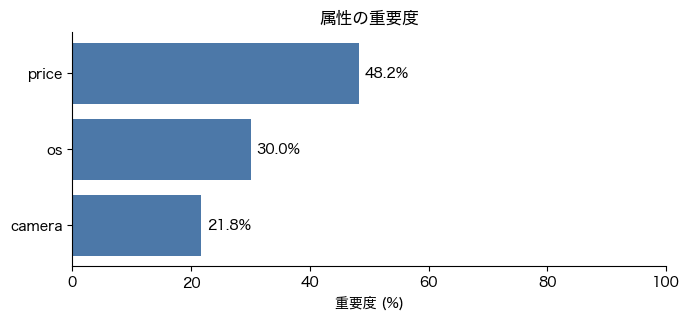

In [16]:
# plot_importance — result メソッドとして呼ぶ
ax = result.plot_importance(title="属性の重要度", show_values=True, sort=True)
ax.set_xlabel("重要度 (%)")
pass

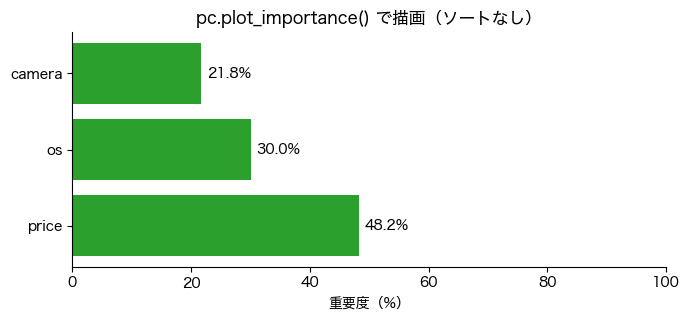

In [17]:
# plot_importance — pc モジュールの関数として呼ぶ（結果は同じ）
ax = pcr.plot_importance(result, color="#2CA02C", sort=False)
ax.set_title("pcr.plot_importance() で描画（ソートなし）")
pass

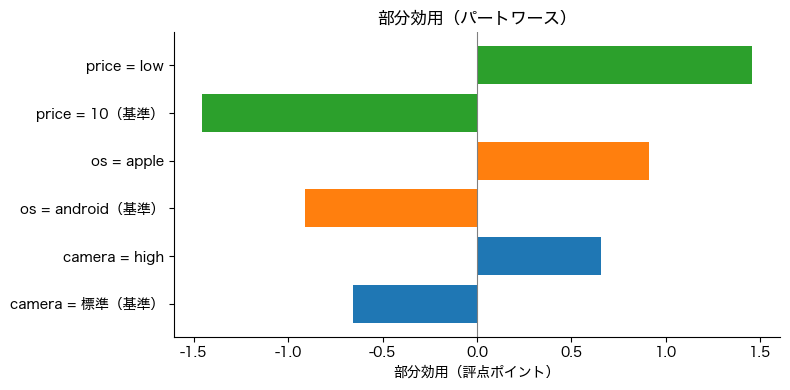

In [18]:
# plot_partworth — result メソッドとして呼ぶ
ax = result.plot_partworth(title="部分効用（パートワース）", show_zero_line=True)
pass

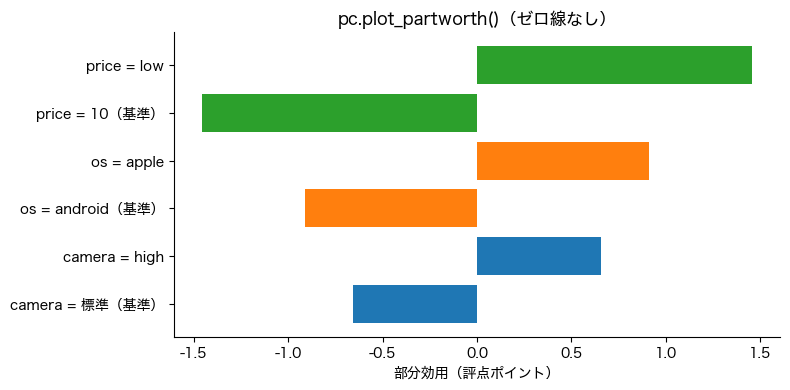

In [19]:
# plot_partworth — pc モジュールの関数として呼ぶ
ax = pcr.plot_partworth(result, show_zero_line=False)
ax.set_title("pcr.plot_partworth()（ゼロ線なし）")
pass

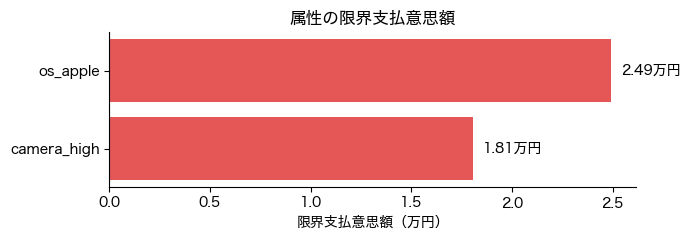

In [20]:
# plot_wtp — result メソッドとして呼ぶ
ax = result.plot_wtp(price_unit="万円", show_values=True, sort=True)
pass

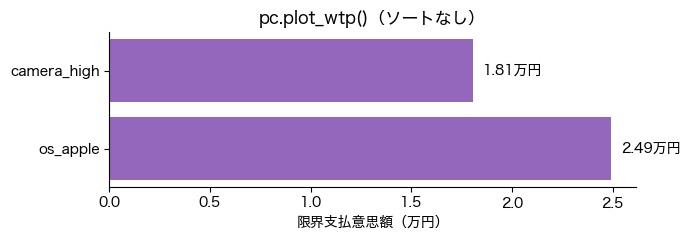

In [21]:
# plot_wtp — pc モジュールの関数として呼ぶ
ax = pcr.plot_wtp(result, price_unit="万円", color="#9467BD", sort=False)
ax.set_title("pcr.plot_wtp()（ソートなし）")
pass